In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [2]:
df = pd.read_csv("gender_classification_v7.csv")
df.head()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female


In [3]:
df["gender"].value_counts()

gender
Female    2501
Male      2500
Name: count, dtype: int64

In [4]:
df.shape

(5001, 8)

In [5]:
df.isna().sum()

long_hair                    0
forehead_width_cm            0
forehead_height_cm           0
nose_wide                    0
nose_long                    0
lips_thin                    0
distance_nose_to_lip_long    0
gender                       0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(1768)

In [7]:
# task is to find out the duplicate values here 

In [8]:
df = df.drop_duplicates()

In [9]:
df.shape

(3233, 8)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3233 entries, 0 to 4995
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   long_hair                  3233 non-null   int64  
 1   forehead_width_cm          3233 non-null   float64
 2   forehead_height_cm         3233 non-null   float64
 3   nose_wide                  3233 non-null   int64  
 4   nose_long                  3233 non-null   int64  
 5   lips_thin                  3233 non-null   int64  
 6   distance_nose_to_lip_long  3233 non-null   int64  
 7   gender                     3233 non-null   object 
dtypes: float64(2), int64(5), object(1)
memory usage: 227.3+ KB


In [11]:
df.describe()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long
count,3233.000000,3233.000000,3233.000000,3233.000000,3233.000000,3233.000000,3233.000000
mean,0.822456,13.217198,5.966038,0.536344,0.557686,0.538509,0.545314
std,0.382188,1.115993,0.549789,0.498755,0.496738,0.498592,0.498019
min,0.000000,11.400000,5.100000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,12.300000,5.500000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,13.200000,5.900000,1.000000,1.000000,1.000000,1.000000
75%,1.000000,14.100000,6.400000,1.000000,1.000000,1.000000,1.000000
max,1.000000,15.500000,7.100000,1.000000,1.000000,1.000000,1.000000


In [12]:
df["gender"]= df["gender"].replace(["Male","Female"],[1,0])

C:\Users\CreativeIT\AppData\Local\Temp\ipykernel_13224\4023084254.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["gender"]= df["gender"].replace(["Male","Female"],[1,0])


In [13]:
df.corr()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
long_hair,1.000000,-0.013151,-0.005145,0.024123,0.042556,0.037514,-0.011362,0.013933
forehead_width_cm,-0.013151,1.000000,0.079665,0.212223,0.212032,0.220566,0.206636,0.323520
forehead_height_cm,-0.005145,0.079665,1.000000,0.180526,0.153438,0.170018,0.183036,0.266843
nose_wide,0.024123,0.212223,0.180526,1.000000,0.394605,0.379767,0.395401,0.661864
nose_long,0.042556,0.212032,0.153438,0.394605,1.000000,0.384860,0.377462,0.638187
lips_thin,0.037514,0.220566,0.170018,0.379767,0.384860,1.000000,0.380805,0.631065
distance_nose_to_lip_long,-0.011362,0.206636,0.183036,0.395401,0.377462,0.380805,1.000000,0.646612
gender,0.013933,0.323520,0.266843,0.661864,0.638187,0.631065,0.646612,1.000000


<Axes: >

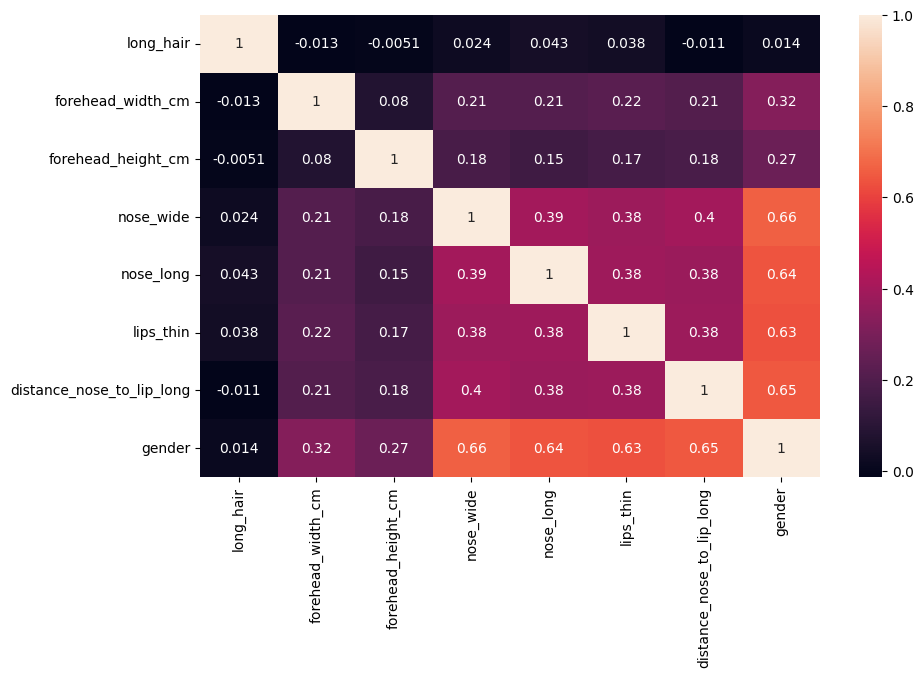

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)

<Axes: xlabel='gender'>

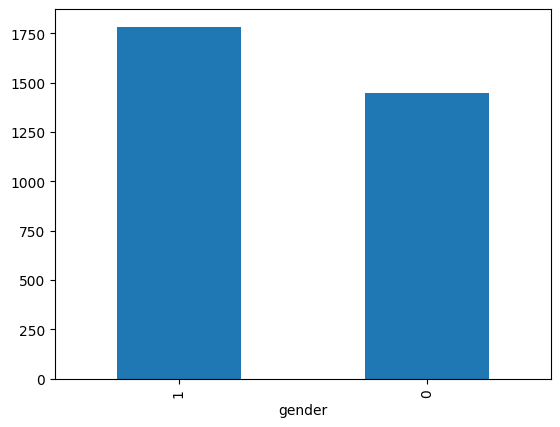

In [15]:
df["gender"].value_counts().plot(kind="bar")

In [16]:
df.columns

Index(['long_hair', 'forehead_width_cm', 'forehead_height_cm', 'nose_wide',
       'nose_long', 'lips_thin', 'distance_nose_to_lip_long', 'gender'],
      dtype='object')

<Axes: xlabel='gender,lips_thin'>

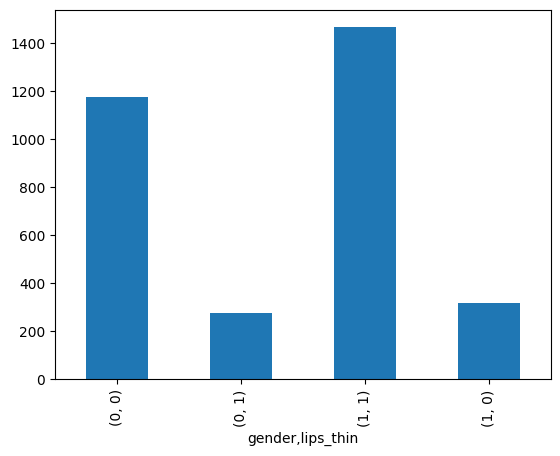

In [17]:
df.groupby("gender")["lips_thin"].value_counts().plot(kind="bar")

In [18]:
df.tail()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
4986,1,11.7,6.1,1,1,0,1,1
4990,1,12.6,5.7,0,0,1,0,0
4992,1,14.1,7.0,1,1,1,1,1
4993,1,11.6,5.9,0,0,0,1,0
4995,1,12.3,6.9,0,1,1,1,1


In [19]:
df.loc[15:20]

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
15,0,12.5,5.2,1,1,1,1,1
16,1,15.2,6.0,1,1,1,1,1
17,1,14.0,5.9,0,0,0,0,0
18,1,11.9,5.2,0,0,0,0,0
19,1,14.4,5.6,1,0,1,1,1
20,1,14.6,6.3,1,1,1,1,1


In [20]:
df.iloc[15:20]

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
15,0,12.5,5.2,1,1,1,1,1
16,1,15.2,6.0,1,1,1,1,1
17,1,14.0,5.9,0,0,0,0,0
18,1,11.9,5.2,0,0,0,0,0
19,1,14.4,5.6,1,0,1,1,1


In [21]:
# data separation
x = df.iloc[:, 0:-1]
y = df.iloc[:,-1]

In [22]:
x

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long
0,1,11.8,6.1,1,0,1,1
1,0,14.0,5.4,0,0,1,0
2,0,11.8,6.3,1,1,1,1
3,0,14.4,6.1,0,1,1,1
4,1,13.5,5.9,0,0,0,0
...,...,...,...,...,...,...,...
4986,1,11.7,6.1,1,1,0,1
4990,1,12.6,5.7,0,0,1,0
4992,1,14.1,7.0,1,1,1,1
4993,1,11.6,5.9,0,0,0,1


In [23]:
y

0       1
1       0
2       1
3       1
4       0
       ..
4986    1
4990    0
4992    1
4993    0
4995    1
Name: gender, Length: 3233, dtype: int64

In [24]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y, test_size=.2, random_state=42)

In [25]:
xtrain.shape,xtest.shape,ytrain.shape,ytest.shape

((2586, 7), (647, 7), (2586,), (647,))

In [26]:
# model 
logis= LogisticRegression()

In [27]:
model = logis.fit(xtrain, ytrain)

In [28]:
model.score(xtrain, ytrain)

0.9501160092807425

In [29]:
model.score(xtest, ytest)

0.9598145285935085

In [30]:
prediction = model.predict(xtest)
prediction

array([0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1,
       1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0,

In [31]:
y

0       1
1       0
2       1
3       1
4       0
       ..
4986    1
4990    0
4992    1
4993    0
4995    1
Name: gender, Length: 3233, dtype: int64

In [32]:
# evaluate the model 
acc_sco= accuracy_score(ytest, prediction)
acc_sco

0.9598145285935085

In [33]:
# classsification report 
clssi_rep= classification_report(ytest,prediction)
clssi_rep

'              precision    recall  f1-score   support\n\n           0       0.95      0.96      0.96       308\n           1       0.96      0.96      0.96       339\n\n    accuracy                           0.96       647\n   macro avg       0.96      0.96      0.96       647\nweighted avg       0.96      0.96      0.96       647\n'

In [34]:
print(clssi_rep)

              precision    recall  f1-score   support

           0       0.95      0.96      0.96       308
           1       0.96      0.96      0.96       339

    accuracy                           0.96       647
   macro avg       0.96      0.96      0.96       647
weighted avg       0.96      0.96      0.96       647



In [35]:
# confusion matrix 
cm = confusion_matrix(ytest, prediction)
cm

array([[296,  12],
       [ 14, 325]])

<Axes: >

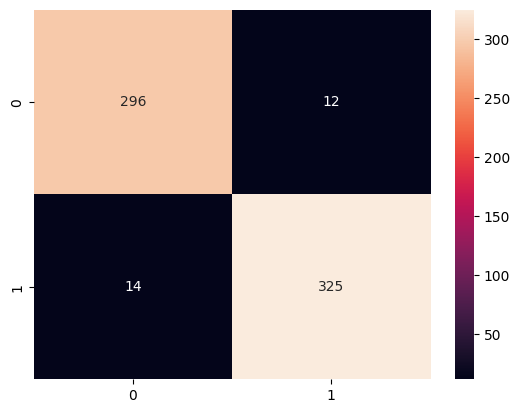

In [36]:
sns.heatmap(cm, annot=True, fmt="g")

In [37]:
ytest.value_counts()

gender
1    339
0    308
Name: count, dtype: int64

In [38]:
xtest.head()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long
1187,0,13.0,5.5,1,0,1,0
1688,1,13.5,5.4,0,1,1,0
1470,1,13.2,5.7,1,0,0,0
30,1,15.3,5.2,1,1,1,1
141,1,13.1,6.2,1,1,1,1


In [39]:
ytest.head()

1187    1
1688    0
1470    0
30      1
141     1
Name: gender, dtype: int64

In [40]:
model.predict([[1,	15.3,	5.2,	1,	1,	1	,1]])

C:\Users\CreativeIT\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1])

In [41]:
prediction

array([0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1,
       1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0,

In [42]:
pred_proba= model.predict_proba(xtest)
pred_proba

array([[5.49245554e-01, 4.50754446e-01],
       [5.95972270e-01, 4.04027730e-01],
       [9.64614773e-01, 3.53852270e-02],
       ...,
       [9.99143867e-01, 8.56132912e-04],
       [4.54275431e-01, 5.45724569e-01],
       [2.96390474e-04, 9.99703610e-01]], shape=(647, 2))

# new with 1 x 

In [43]:
df.head()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,1
1,0,14.0,5.4,0,0,1,0,0
2,0,11.8,6.3,1,1,1,1,1
3,0,14.4,6.1,0,1,1,1,1
4,1,13.5,5.9,0,0,0,0,0


In [44]:
x = df[["forehead_width_cm"]]
y = df[["gender"]]

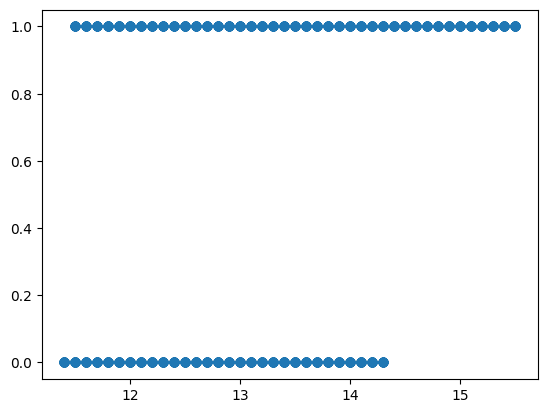

In [45]:
plt.scatter(x,y)

In [46]:
model1= logis.fit(x,y)
model1.score(x,y)

C:\Users\CreativeIT\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.5991339313331271

In [47]:
pred_1x= model1.predict(x)

In [48]:
pred_1x

array([0, 1, 0, ..., 1, 0, 0], shape=(3233,))

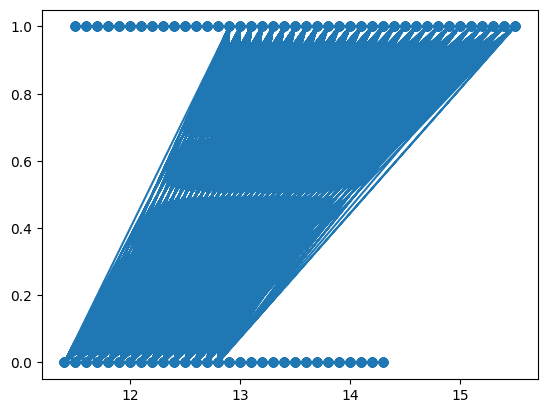

In [49]:
plt.scatter(x,y)
plt.plot(x, pred_1x)

In [50]:
pred_1x_proba= model1.predict_proba(x)[:,1]
pred_1x_proba

array([0.3401566 , 0.67570852, 0.3401566 , ..., 0.68946218, 0.31226088,
       0.41455633], shape=(3233,))

In [51]:
import numpy as np 

newx= np.linspace(x.min(), x.max(), 10000)

In [52]:
pred_with_new_x= model1.predict(newx)
pred_with_new_x

C:\Users\CreativeIT\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0, 0, 0, ..., 1, 1, 1], shape=(10000,))

In [53]:
pred_with_new_proba= model1.predict_proba(newx)[:,1]
pred_with_new_proba

C:\Users\CreativeIT\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0.28566246, 0.28571558, 0.28576871, ..., 0.8436848 , 0.84371912,
       0.84375345], shape=(10000,))

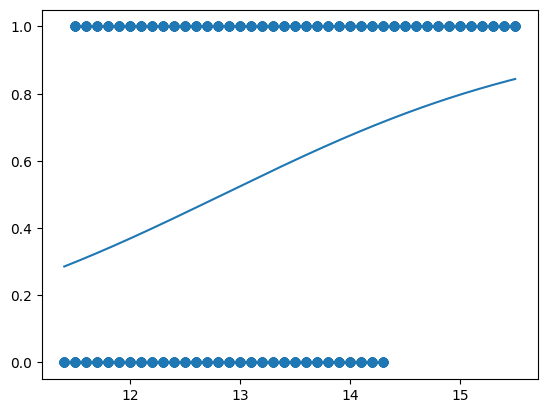

In [54]:

plt.scatter(x,y)
plt.plot(newx,pred_with_new_proba )

In [55]:
import pickle

In [56]:
model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [57]:
pickle.dump(model, open("gender_classi.pkl", "wb"))


In [59]:
model.predict([[23]])

C:\Users\CreativeIT\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1])

In [60]:
x

,forehead_width_cm
0,11.8
1,14.0
2,11.8
3,14.4
4,13.5
...,...
4986,11.7
4990,12.6
4992,14.1
4993,11.6
